# The Laplace Transform as a Generalization of the Fourier Transform

The **Fourier transform** decomposes a signal into pure sinusoids (complex exponentials on the imaginary axis).  
The **Laplace transform** does the same, but over the entire complex plane — making it strictly more general.

The key insight:  
> Setting $s = j\omega$ in the Laplace transform recovers exactly the Fourier transform.

This notebook builds that idea from scratch, and shows *why* the generalization matters.

## 1. Definitions Side by Side

### Fourier Transform
$$\hat{f}(\omega) = \mathcal{F}\{f\}(\omega) = \int_{-\infty}^{\infty} f(t)\, e^{-j\omega t}\, dt$$

The kernel $e^{-j\omega t}$ is a **pure oscillation** — it has magnitude 1 for all $t$.  
This means the integral only converges if $f(t)$ decays fast enough on its own.

---

### (Bilateral) Laplace Transform
$$F(s) = \mathcal{L}\{f\}(s) = \int_{-\infty}^{\infty} f(t)\, e^{-st}\, dt, \qquad s = \sigma + j\omega \in \mathbb{C}$$

The kernel is $e^{-st} = e^{-\sigma t} \cdot e^{-j\omega t}$:  
- $e^{-j\omega t}$ — the oscillatory part (same as Fourier)  
- $e^{-\sigma t}$ — a **real exponential envelope** that can *force convergence*

---

### The Connection
$$F(j\omega) = \mathcal{L}\{f\}(s)\big|_{s=j\omega} = \int_{-\infty}^{\infty} f(t)\, e^{-j\omega t}\, dt = \hat{f}(\omega)$$

So the Fourier transform is the restriction of the Laplace transform to the **imaginary axis** $s = j\omega$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal
import sympy as sp

plt.rcParams.update({"figure.dpi": 120, "font.size": 12})

## 2. Visualising the Complex $s$-Plane

The Laplace transform is defined over the entire complex plane.  
The Fourier transform lives only on the **imaginary axis** (the vertical line $\sigma = 0$).

The plot below shows:
- The full $s$-plane where $\mathcal{L}$ is evaluated
- The imaginary axis $s = j\omega$, which is the domain of $\mathcal{F}$
- A shaded **Region of Convergence (ROC)** — the strip in which the Laplace integral actually converges for a given signal

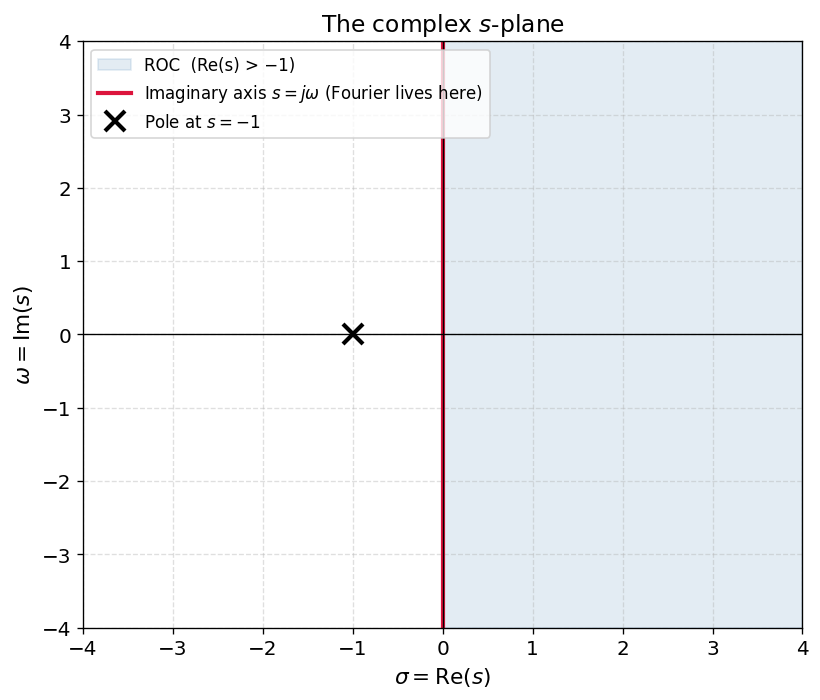

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

# Shade the ROC: example — causal signal e^{-at}u(t) with a=1 has ROC Re(s) > -1
ax.axhspan(-4, 4, xmin=0.5, xmax=1.0, alpha=0.15, color="steelblue", label="ROC  (Re(s) > −1)")

# Imaginary axis — Fourier domain
ax.axvline(x=0, color="crimson", linewidth=2.5, label=r"Imaginary axis $s=j\omega$ (Fourier lives here)")

# Axes
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

# Mark a pole at s = -1
ax.plot(-1, 0, "kx", markersize=12, markeredgewidth=2.5, label="Pole at $s=-1$")

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel(r"$\sigma = \mathrm{Re}(s)$", fontsize=13)
ax.set_ylabel(r"$\omega = \mathrm{Im}(s)$", fontsize=13)
ax.set_title("The complex $s$-plane", fontsize=14)
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Where the Fourier Transform Fails

The Fourier transform requires the integral $\int_{-\infty}^{\infty} |f(t)|\, dt < \infty$ (absolute integrability), or at least square-integrability in $L^2$.

Consider the **growing exponential** $f(t) = e^{+t}\, u(t)$ (where $u(t)$ is the unit step).  
Its magnitude grows without bound, so the Fourier integral **diverges**.

The Laplace transform multiplies by $e^{-\sigma t}$ before integrating.  
Choose $\sigma > 1$ (i.e., $\text{Re}(s) > 1$) and the product $e^{t} \cdot e^{-\sigma t} = e^{-({\sigma-1})t}$ now *decays* — the integral converges.

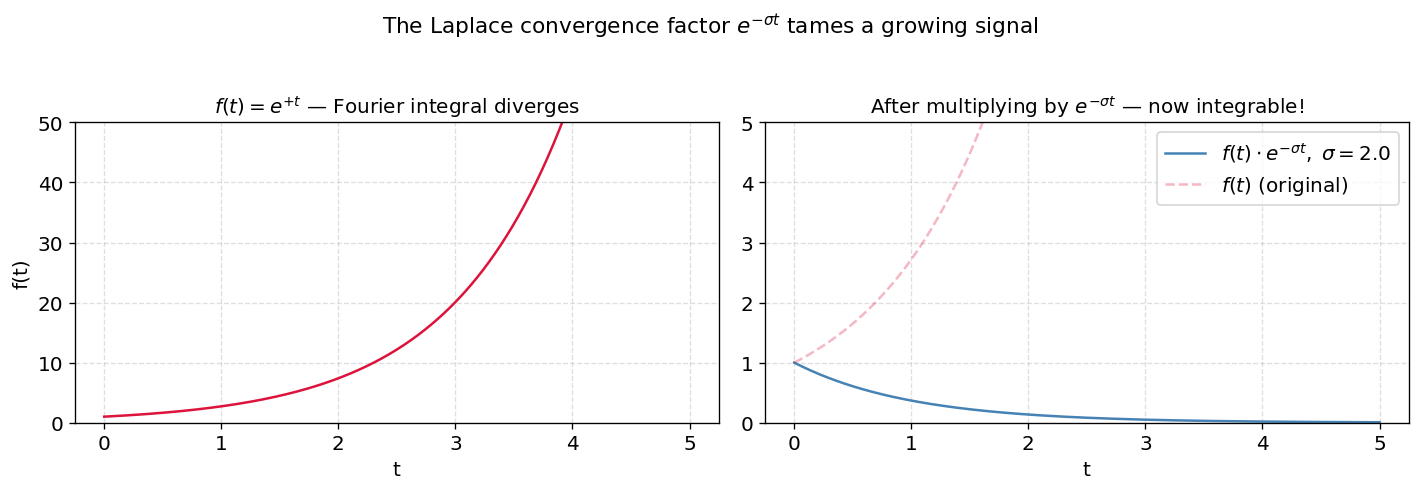

Numerical 'Fourier' integral (truncated at t=5): 147.4  ← huge / diverges
Numerical Laplace integral at sigma=2.0:       0.9933  ← finite


In [ ]:
t = np.linspace(0, 5, 500)

# The growing exponential  f(t) = e^{+t} u(t)
f = np.exp(t)

# Laplace "convergence factor" for a chosen sigma > 1
sigma = 2.0
damped = f * np.exp(-sigma * t)   # f(t) * e^{-sigma t}  — this decays!

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, f, color="crimson")
axes[0].set_title(r"$f(t) = e^{+t}$ — Fourier integral diverges", fontsize=12)
axes[0].set_xlabel("t")
axes[0].set_ylabel("f(t)")
axes[0].set_ylim(0, 50)
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(t, damped, color="steelblue",
             label=rf"$f(t)\cdot e^{{-\sigma t}},\; \sigma={sigma}$")
axes[1].plot(t, f, color="crimson", alpha=0.3, linestyle="--", label=r"$f(t)$ (original)")
axes[1].set_title(r"After multiplying by $e^{-\sigma t}$ — now integrable!", fontsize=12)
axes[1].set_xlabel("t")
axes[1].set_ylim(0, 5)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle(r"The Laplace convergence factor $e^{-\sigma t}$ tames a growing signal",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Numerical 'Fourier' integral (truncated at t=5): {np.trapezoid(f, t):.1f}  ← huge / diverges")
print(f"Numerical Laplace integral at sigma={sigma}:       {np.trapezoid(damped, t):.4f}  ← finite")

## 4. Verifying the Connection Analytically with SymPy

For a well-behaved signal such as $f(t) = e^{-at}\,u(t)$ with $a > 0$, both transforms exist.  
We verify symbolically that $F(s)\big|_{s=j\omega} = \hat{f}(\omega)$.

$$\mathcal{L}\{e^{-at}u(t)\} = \frac{1}{s+a}, \qquad \text{Re}(s) > -a$$

$$\mathcal{F}\{e^{-at}u(t)\} = \frac{1}{j\omega + a}$$

Setting $s = j\omega$ in the Laplace result immediately gives the Fourier result.

In [ ]:
t_sym, s, omega, a = sp.symbols("t s omega a", real=True, positive=True)

f_sym = sp.exp(-a * t_sym)   # f(t) = e^{-at}  (for t >= 0, i.e. u(t) assumed)

# Laplace transform  F(s) = integral_0^inf f(t) e^{-st} dt
F_s = sp.integrate(f_sym * sp.exp(-s * t_sym), (t_sym, 0, sp.oo))
F_s = sp.simplify(F_s)

# Substitute s = j*omega to recover the Fourier transform
F_jw = F_s.subs(s, sp.I * omega)
F_jw = sp.simplify(F_jw)

# Direct Fourier transform
F_fourier = sp.integrate(f_sym * sp.exp(-sp.I * omega * t_sym), (t_sym, 0, sp.oo))
F_fourier = sp.simplify(F_fourier)

print("Laplace transform  F(s)         =", F_s)
print()
print("F(s) evaluated at s = jω        =", F_jw)
print()
print("Fourier transform  F̂(ω) directly=", F_fourier)
print()
print("Are they equal?", sp.simplify(F_jw - F_fourier) == 0)

Laplace transform  F(s)         = 1/(a + s)

F(s) evaluated at s = jω        = 1/(a + I*omega)

Fourier transform  F̂(ω) directly= 1/(a + I*omega)

Are they equal? True


## 5. Magnitude Response Along the Imaginary Axis

The Fourier spectrum $|\hat{f}(\omega)|$ is the **magnitude of $F(s)$ evaluated along $s = j\omega$**.

For $f(t) = e^{-at}u(t)$:
$$F(s) = \frac{1}{s+a} \implies |\hat{f}(\omega)| = \frac{1}{\sqrt{\omega^2 + a^2}}$$

The plot below shows $|F(s)|$ over the full $s$-plane as a surface, with the Fourier spectrum highlighted as the cross-section at $\sigma = 0$.

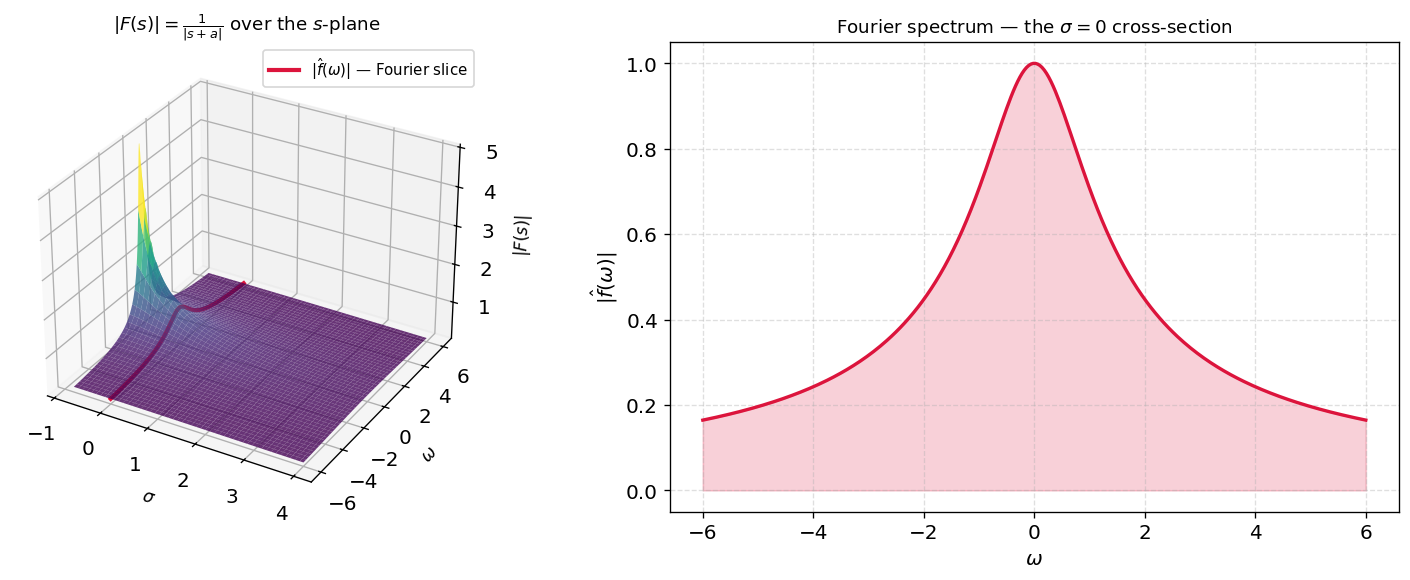

In [ ]:
a_val = 1.0
sigma_vals = np.linspace(-0.8, 4, 200)    # Re(s) — avoid the pole at sigma = -a
omega_vals = np.linspace(-6, 6, 300)       # Im(s)

SIG, OMG = np.meshgrid(sigma_vals, omega_vals)
S = SIG + 1j * OMG

# F(s) = 1 / (s + a)
F_surface = np.abs(1.0 / (S + a_val))
F_surface = np.clip(F_surface, 0, 6)      # clip near-pole spike for visualisation

fig = plt.figure(figsize=(13, 5))

# --- 3-D surface ---
ax3d = fig.add_subplot(121, projection="3d")
ax3d.plot_surface(SIG, OMG, F_surface, cmap="viridis", alpha=0.8, linewidth=0)
# Overlay the Fourier cross-section at sigma=0
omega_line = np.linspace(-6, 6, 300)
fourier_mag = np.abs(1.0 / (1j * omega_line + a_val))
ax3d.plot(np.zeros_like(omega_line), omega_line, fourier_mag,
          color="crimson", linewidth=2.5, label=r"$|\hat{f}(\omega)|$ — Fourier slice")
ax3d.set_xlabel(r"$\sigma$", fontsize=10)
ax3d.set_ylabel(r"$\omega$", fontsize=10)
ax3d.set_zlabel(r"$|F(s)|$", fontsize=10)
ax3d.set_title(r"$|F(s)| = \frac{1}{|s+a|}$ over the $s$-plane", fontsize=11)
ax3d.legend(fontsize=9)

# --- 2-D Fourier spectrum slice ---
ax2d = fig.add_subplot(122)
ax2d.plot(omega_line, fourier_mag, color="crimson", linewidth=2)
ax2d.fill_between(omega_line, fourier_mag, alpha=0.2, color="crimson")
ax2d.set_xlabel(r"$\omega$", fontsize=12)
ax2d.set_ylabel(r"$|\hat{f}(\omega)|$", fontsize=12)
ax2d.set_title(r"Fourier spectrum — the $\sigma=0$ cross-section", fontsize=11)
ax2d.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 6. The Region of Convergence (ROC) and When Fourier Exists

The Laplace transform converges only for values of $\sigma = \text{Re}(s)$ in a vertical strip called the **Region of Convergence (ROC)**.

The Fourier transform of $f(t)$ exists **if and only if the imaginary axis $\sigma = 0$ lies inside the ROC**.

| Signal $f(t)$ | ROC | Imaginary axis inside ROC? |
|---|---|---|
| $e^{-t}u(t)$ | $\text{Re}(s) > -1$ | ✅ Yes — Fourier OK |
| $e^{+t}u(t)$ | $\text{Re}(s) > +1$ | ❌ No — Fourier diverges |
| $u(t)$ (step) | $\text{Re}(s) > 0$ | Boundary — Fourier needs $\delta(\omega)$ |

The cell below plots the ROCs for these three signals.

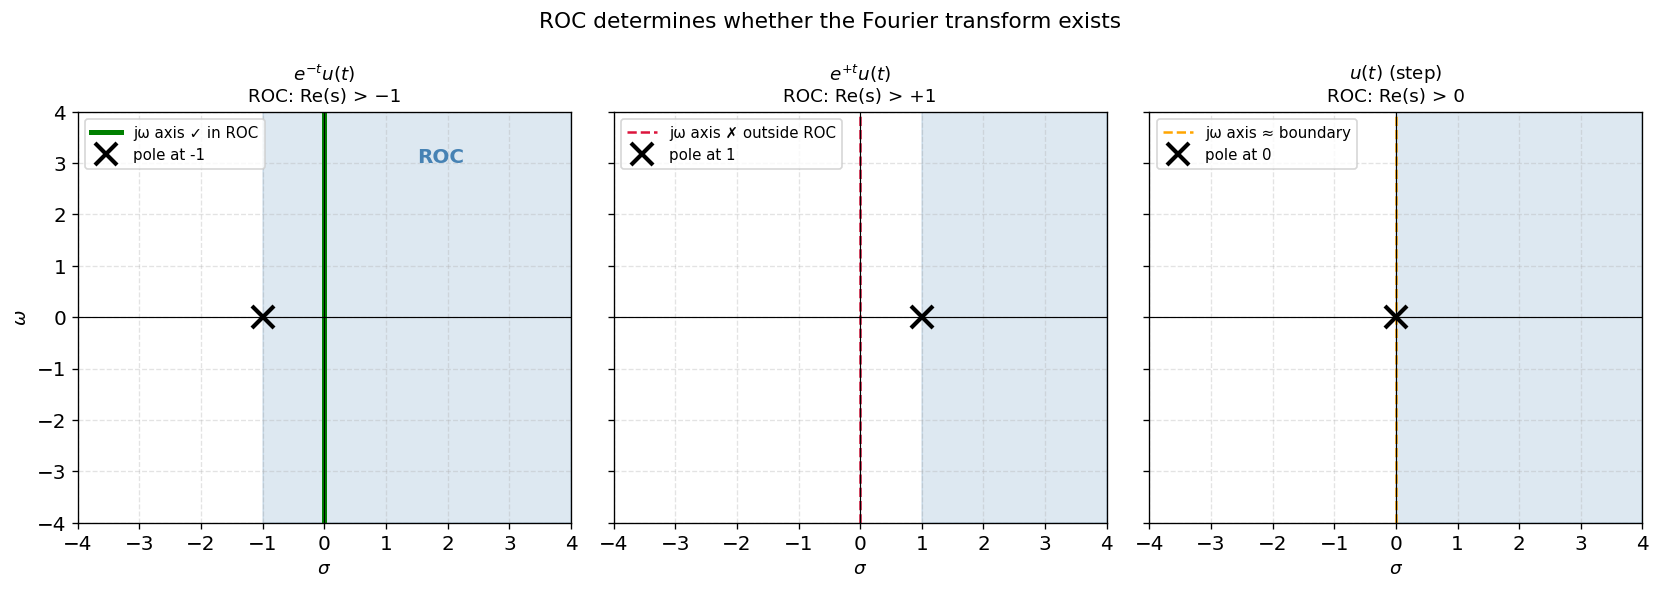

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

cases = [
    dict(title=r"$e^{-t}u(t)$" + "\nROC: Re(s) > −1",
         roc_start=-1, roc_end=4, pole=-1, fourier_ok=True),
    dict(title=r"$e^{+t}u(t)$" + "\nROC: Re(s) > +1",
         roc_start=1, roc_end=4, pole=1, fourier_ok=False),
    dict(title=r"$u(t)$ (step)" + "\nROC: Re(s) > 0",
         roc_start=0, roc_end=4, pole=0, fourier_ok=None),
]

for ax, c in zip(axes, cases):
    # Shade ROC
    ax.axhspan(-4, 4, xmin=(c["roc_start"] + 4) / 8,
               xmax=1.0, alpha=0.18, color="steelblue")

    # Imaginary axis
    lw = 3 if c["fourier_ok"] else 1.5
    col = "green" if c["fourier_ok"] else ("orange" if c["fourier_ok"] is None else "crimson")
    ls  = "-"     if c["fourier_ok"] else ("--" if c["fourier_ok"] is None else "--")
    ax.axvline(0, color=col, linewidth=lw, linestyle=ls,
               label="jω axis" + (" ✓ in ROC" if c["fourier_ok"] else
                                   (" ≈ boundary" if c["fourier_ok"] is None else " ✗ outside ROC")))

    # Pole
    ax.plot(c["pole"], 0, "kx", markersize=13, markeredgewidth=2.5,
            label=f"pole at {c['pole']}")

    ax.axhline(0, color="black", linewidth=0.7)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_title(c["title"], fontsize=11)
    ax.set_xlabel(r"$\sigma$", fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.35)

axes[0].set_ylabel(r"$\omega$", fontsize=11)

# Add ROC label once
axes[0].text(1.5, 3.0, "ROC", fontsize=12, color="steelblue", fontweight="bold")
fig.suptitle("ROC determines whether the Fourier transform exists", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Concept | Fourier $\mathcal{F}$ | Laplace $\mathcal{L}$ |
|---|---|---|
| Integration variable | $\omega \in \mathbb{R}$ (imaginary axis) | $s \in \mathbb{C}$ (full plane) |
| Kernel | $e^{-j\omega t}$ | $e^{-st} = e^{-\sigma t} e^{-j\omega t}$ |
| Convergence requirement | $f$ must be absolutely/square integrable | Weaker: $f$ only needs to be dominated by $e^{\sigma t}$ for some $\sigma$ |
| Handles growing signals | ❌ | ✅ (if ROC ∋ appropriate $\sigma$) |
| Relation | $\hat{f}(\omega) = F(j\omega)$ | $F(s)$ generalises $\hat{f}(\omega)$ |

**Key takeaway:** The Laplace transform extends the Fourier transform from the imaginary axis into the full complex plane. The extra degree of freedom $\sigma = \text{Re}(s)$ acts as an exponential convergence factor that tames signals the Fourier transform cannot handle.  When the imaginary axis lies inside the ROC, the two transforms agree exactly on that axis.

## Inverse Laplace: Bromwich Line and Residue Example

For inverse Laplace, we do **not** integrate on the real axis. We integrate on a vertical line in the complex plane:

$$
f(t)=\mathcal{L}^{-1}\{F\}(t)=\frac{1}{2\pi i}\int_{\sigma-i\infty}^{\sigma+i\infty} e^{st}F(s)\,ds
$$

with $s=\sigma+i\omega$, $\omega\in\mathbb{R}$, and $\sigma$ chosen to the right of all singularities of $F$.

Equivalent real-variable form:

$$
f(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty} e^{(\sigma+i\omega)t}F(\sigma+i\omega)\,d\omega
$$

So the integral is over real $\omega$, but sampled along the vertical line $\operatorname{Re}(s)=\sigma$ (the **Bromwich line**).

### Full residue calculation for $F(s)=\frac{1}{s-a}$

For $t>0$,

$$
f(t)=\frac{1}{2\pi i}\int_{\sigma-i\infty}^{\sigma+i\infty}\frac{e^{st}}{s-a}\,ds,\qquad \sigma>\operatorname{Re}(a)
$$

1. Integrand: $g(s)=\frac{e^{st}}{s-a}$, with one pole at $s=a$.
2. Close the contour to the **left** for $t>0$, where $e^{st}=e^{\operatorname{Re}(s)t}e^{i\operatorname{Im}(s)t}$ decays on the large semicircle.
3. By the residue theorem,

$$
\oint g(s)\,ds = 2\pi i\,\operatorname{Res}(g,a)
$$

4. Residue at the simple pole:

$$
\operatorname{Res}\!\left(\frac{e^{st}}{s-a},a\right)=e^{at}
$$

5. Arc contribution vanishes as radius $R\to\infty$, so the Bromwich integral equals $2\pi i\,e^{at}$.
6. Multiply by $1/(2\pi i)$:

$$
f(t)=e^{at},\qquad t>0
$$

For unilateral Laplace this is typically written as $e^{at}u(t)$.

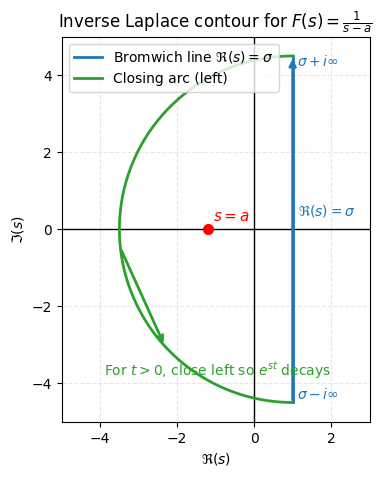

In [ ]:
# Small contour sketch for the inverse Laplace example F(s)=1/(s-a)
import numpy as np
import matplotlib.pyplot as plt

a = -1.2
sigma = 1.0
R = 4.5

fig, ax = plt.subplots(figsize=(7, 5))

# Axes
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

# Bromwich line Re(s)=sigma
ax.plot([sigma, sigma], [-R, R], color="tab:blue", linewidth=2, label=r"Bromwich line $\Re(s)=\sigma$")
ax.annotate("", xy=(sigma, R), xytext=(sigma, -R), arrowprops=dict(arrowstyle="->", color="tab:blue", linewidth=2))

# Left semicircle (closure for t>0)
theta = np.linspace(np.pi/2, 3*np.pi/2, 300)
x_arc = sigma + R * np.cos(theta)
y_arc = R * np.sin(theta)
ax.plot(x_arc, y_arc, color="tab:green", linewidth=2, label="Closing arc (left)")
ax.annotate("", xy=(x_arc[220], y_arc[220]), xytext=(x_arc[160], y_arc[160]), arrowprops=dict(arrowstyle="->", color="tab:green", linewidth=2))

# Pole at s=a
ax.plot(a, 0, "ro", markersize=7)
ax.text(a + 0.12, 0.22, r"$s=a$", color="red", fontsize=11)

# Labels
ax.text(sigma + 0.1, R - 0.25, r"$\sigma+i\infty$", color="tab:blue")
ax.text(sigma + 0.1, -R + 0.1, r"$\sigma-i\infty$", color="tab:blue")
ax.text(sigma + 0.15, 0.35, r"$\Re(s)=\sigma$", color="tab:blue")
ax.text(-3.9, -3.8, r"For $t>0$, close left so $e^{st}$ decays", color="tab:green")

ax.set_xlim(-5, 3)
ax.set_ylim(-5, 5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$\Re(s)$")
ax.set_ylabel(r"$\Im(s)$")
ax.set_title(r"Inverse Laplace contour for $F(s)=\frac{1}{s-a}$")
ax.grid(alpha=0.3, linestyle="--")
ax.legend(loc="upper left")
plt.show()

## 7. Why `e^{st}` Are Fundamental Building Blocks (But Not an Orthonormal Basis)

It is correct to think of Laplace analysis as expanding a signal using exponentials `e^{st}`.  
However, this is **not** an orthonormal-basis expansion in the Hilbert-space/Fourier-series sense.

### Why they are fundamental building blocks

The inverse Laplace formula reconstructs `f(t)` from weighted exponentials:

$$
f(t) = \frac{1}{2\pi i}\int_{\sigma-i\infty}^{\sigma+i\infty} F(s)e^{st}\,ds
$$

So the family `e^{st}` provides the elementary modes from which signals are reconstructed (continuously, along a contour in the complex plane).

### Why this is not an orthonormal basis

For an orthonormal basis $\phi_k$, we expect discrete coefficients and orthogonality:

$$
\langle \phi_m,\phi_n\rangle = \delta_{mn}
$$

In Laplace analysis, none of the usual orthonormal-basis properties generally hold:

- The index `s` is **continuous and complex**, not a discrete integer index.
- The modes $e^{st}$ are generally **not orthogonal** under the standard $L^2$ inner product.
- For many `s`, these exponentials are not even in $L^2$, so Hilbert-space orthonormality is not the right framework.
- Reconstruction uses a **contour integral + analytic structure** (ROC, poles, residues), not a simple inner-product projection onto orthonormal vectors.



## Pole-Zero-Gain Form (KaTeX)

A standard rational Laplace-domain form is:

$$
F(s)=K\frac{\prod_i (s-z_i)}{\prod_k (s-p_k)}
$$

Meanings:

$$
F(z_i)=0 \quad \text{(zeros)}
$$

$$
\lim_{s\to p_k}|F(s)|=\infty \quad \text{(poles)}
$$

Expanded product form:

$$
F(s)=\frac{K\,(s-z_1)(s-z_2)\cdots(s-z_m)}{(s-p_1)(s-p_2)\cdots(s-p_n)}
$$

For **rational** functions, `F(s)` is fully specified by poles, zeros, and gain `K`.

For Laplace signal interpretation, include the ROC as well (same algebraic `F(s)` can represent different time-domain signals under different ROCs).

## Clarification: Rational Function and the Two Statements

A **rational function** of `s` is a ratio of polynomials:

$$
F(s)=\frac{N(s)}{D(s)}
$$

Example:

$$
F(s)=\frac{2(s+3)}{(s+1)(s+4)}
$$

Here, zeros are roots of `N(s)`, poles are roots of `D(s)`, and `2` is the gain `K`.

### Statement 1: "Fully specified by poles, zeros, and gain"

For rational `F(s)`, knowing all poles, all zeros, and `K` lets you reconstruct the same algebraic function.

### Statement 2: "For Laplace interpretation, include ROC"

In bilateral Laplace, the same algebraic expression can represent different time-domain signals depending on ROC.

Classic example:

$$
F(s)=\frac{1}{s+1}
$$

- ROC $\operatorname{Re}(s)>-1$ corresponds to $e^{-t}u(t)$ (right-sided).
- ROC $\operatorname{Re}(s)<-1$ corresponds to $-e^{-t}u(-t)$ (left-sided).

So poles-zeros-gain define the algebraic `F(s)`, and ROC selects the actual time-domain signal.